# Rapport d'Étude : Analyse Statistique et Suivi des Capteurs Industriels

Module : SAÉ 204 - Base de données et Statistiques (BUT Informatique 1ère année)
Groupe : Ouameur Aïssa, Ounays Mayeux, Alban Platel.

Pour améliorer les chaînes de production de l'usine, il faut s'assurer que les capteurs soient totalement fiables. Le problème actuel, c'est que les opérateurs vérifient les données à l'œil nu. Ça prend beaucoup de temps et ça laisse de la place aux erreurs humaines.

L'objectif de ce projet est de régler ce problème en deux parties :

   * Automatiser la détection des erreurs : Créer des algorithmes en Python pour repérer tout de suite les problèmes (bruit excessif, dérives de mesure).

   * Gérer le cycle de vie des capteurs : Utiliser une base de données PostgreSQL pour stocker l'historique de chaque capteur (mise en service, recalibrage, fin de vie) et faciliter le travail de la maintenance.

**1. Dictionnaire de données**

Pour bien comprendre l'architecture de notre base de données existante et préparer son évolution, nous avons établi le dictionnaire de données suivant. Il précise les types de données et identifie les clés primaires (PK) et étrangères (FK) pour garantir l'intégrité référentielle.

| table\_name | column\_name | data\_type | is\_nullable |
| :--- | :--- | :--- | :--- |
| controller | controllerid | integer | NO |
| controller | modelid | integer | NO |
| controller | serialnumber | text | NO |
| controlmeasurement | sensorid | integer | NO |
| controlmeasurement | controllerid | integer | NO |
| controlmeasurement | sensortimestamp | timestamp without time zone | NO |
| controlmeasurement | controltimestamp | timestamp without time zone | NO |
| controlmeasurement | controlvalue | double precision | NO |
| model | unit | text | NO |
| model | modelid | integer | NO |
| model | brand | text | NO |
| model | model | text | NO |
| model | name | text | NO |
| sensor | validity | interval | NO |
| sensor | sensorid | integer | NO |
| sensor | serialnumber | text | NO |
| sensor | position | text | NO |
| sensor | modelid | integer | NO |
| sensormeasurement | timestamp | timestamp without time zone | NO |
| sensormeasurement | sensorid | integer | NO |
| sensormeasurement | sensorvalue | double precision | NO |


**2. Test de connexion à la base de données**

Pour réaliser cette SAÉ, nous avons commencé par exporter la base de données distante afin de l'installer en local sur notre machine. Cette manipulation nous permet de travailler plus rapidement, sans problème de réseau, et d'avoir les droits nécessaires pour exécuter nos requêtes et modifier la structure de la base.

Le script ci-dessous montre comment nous avons utilisé la bibliothèque psycopg. Elle permet d'établir la connexion entre notre code Python (Jupyter) et notre serveur PostgreSQL local

In [18]:
import psycopg

conn_params = {
    "host": "localhost",
    "dbname": "postgres",
    "user": "postgres",
    "password": "admin"
}

try:
    with psycopg.connect(**conn_params) as conn:
        print("Connection successful!")
        with conn.cursor() as cur:
            cur.execute("SELECT version();")
            print(cur.fetchone())
except psycopg.OperationalError as e:
    print(f"Connection failed: {e}")


Connection successful!
('PostgreSQL 18.3 on x86_64-windows, compiled by msvc-19.44.35225, 64-bit',)


Ce résultat confirme que la connexion à la base de données est opérationnelle. Nous pouvons donc passer à l'étape suivante.

# Script 1 — Extraction des erreurs de mesure brutes

Avant tout calcul statistique, on observe les données brutes. Pour évaluer la précision d’un capteur, on compare ses mesures avec les valeurs de référence du laboratoire. L’erreur de mesure correspond à `controlvalue - sensorvalue`.

Le script suivant effectue la jointure entre `sensormeasurement` et `controlmeasurement`, puis affiche les 50 premières erreurs pour chaque capteur.

In [19]:
import psycopg

def get_all_sensor_ids(conn):
    with conn.cursor() as cur:
        cur.execute("SELECT DISTINCT sensorid FROM sensormeasurement ORDER BY sensorid;")
        return [row[0] for row in cur.fetchall()]

def test_single_sensor(conn, sensor_id):
    with conn.cursor() as cur:
        cur.execute("""
            SELECT sensormeasurement.sensorid,
                   controlmeasurement.controlvalue - sensormeasurement.sensorvalue AS diff
            FROM controlmeasurement
            JOIN sensormeasurement
                ON controlmeasurement.sensortimestamp = sensormeasurement.timestamp
               AND controlmeasurement.sensorid = sensormeasurement.sensorid
            WHERE controlmeasurement.sensorid = %s
            ORDER BY controlmeasurement.controltimestamp
            LIMIT 50;
        """, (sensor_id,))

        results = cur.fetchall()

        print(f"\n--- Testing Sensor {sensor_id} ---")
        if not results:
            print("No data found.")
            return

        for row in results:
            print(f"Sensor {row[0]} | Difference: {row[1]}")

if __name__ == "__main__":
    conn_params = {
        "host": "localhost",
        "dbname": "postgres",
        "user": "postgres",
        "password": "admin"
    }

    with psycopg.connect(**conn_params) as conn:
        sensor_ids = get_all_sensor_ids(conn)

        for s_id in sensor_ids:
            test_single_sensor(conn, s_id)


--- Testing Sensor 1 ---
Sensor 1 | Difference: -0.6928256070072949
Sensor 1 | Difference: -0.42472458437324756
Sensor 1 | Difference: -0.19717837492203405
Sensor 1 | Difference: -0.05734016940635911
Sensor 1 | Difference: 0.14345425626137076
Sensor 1 | Difference: -0.37765161701976624
Sensor 1 | Difference: -0.38994523019952476
Sensor 1 | Difference: 0.4336675151979643
Sensor 1 | Difference: 0.7761312024213797
Sensor 1 | Difference: -0.15902853772262193
Sensor 1 | Difference: -0.0590040671430998
Sensor 1 | Difference: 0.4418077118033801
Sensor 1 | Difference: 0.5576625971798089
Sensor 1 | Difference: -0.02724000068365151
Sensor 1 | Difference: -0.0610747926891686
Sensor 1 | Difference: -0.14927230955878212
Sensor 1 | Difference: 0.3453796731956025
Sensor 1 | Difference: 0.565314546846384
Sensor 1 | Difference: 0.19167603339857386
Sensor 1 | Difference: 0.8958946595656778
Sensor 1 | Difference: -0.1490143137199928
Sensor 1 | Difference: -0.08535771270845571
Sensor 1 | Difference: -0.1

### 2.1.2 Analyse comparative des erreurs brutes (Capteurs 1 à 7)

En observant les 50 premières erreurs de mesure (`controlvalue - sensorvalue`) pour les 7 capteurs, nous remarquons des comportements très hétérogènes. Cette première analyse visuelle permet de classer l'état du parc en quatre catégories :

1. **Les capteurs fiables (Capteurs 1 et 6)**
    * **Capteur 1** : Il sert de référence. Ses erreurs sont faibles, stables et centrées autour de zéro (généralement comprises entre -0.90 et +0.90).
    * **Capteur 6** : C’est le capteur le plus précis du lot. Sa dispersion est minime (rarement au-delà de $\pm0.19$) et son comportement est exemplaire.

2. **Les capteurs bruités (Capteurs 2, 3 et 7)**
    * **Capteurs 2, 3 et 7** : Leurs mesures présentent une dispersion beaucoup plus importante que celle du capteur de référence. On relève de nombreux écarts supérieurs à $\pm1.50$ (ex : -1.76 pour le capteur 2, +1.75 pour le capteur 3, -1.50 pour le capteur 7). Le niveau de bruit est donc anormalement élevé et nécessitera un diagnostic approfondi.

3. **Le capteur instable avec amorce de dérive (Capteur 5)**
    * **Capteur 5** : Si les toutes premières mesures sont proches de zéro, l'erreur s'amplifie rapidement. On observe de forts pics d'instabilité, plongeant souvent dans des valeurs très négatives (-2.17, -2.76, -3.91) tout en conservant quelques rebonds positifs (+1.85). Cela traduit un capteur qui se dérègle progressivement et perd toute sa stabilité au fil du temps.

4. **Le capteur totalement défaillant (Capteur 4)**
    * **Capteur 4** : Ce capteur ne produit plus aucune mesure cohérente. Les erreurs relevées sont aberrantes, allant de -5.49 à +5.79. Son dérèglement est massif, il est devenu inexploitable pour le contrôle qualité.

**Objectif pour la suite de l’étude :**
Cette première approche empirique suggère une panne sévère pour les capteurs 4 et 5, et un problème de bruit important pour les capteurs 2, 3 et 7. Afin de confirmer mathématiquement ces observations, nous allons utiliser nos scripts Python pour calculer des indicateurs statistiques précis (moyenne, écart-type, lois de probabilité, p-valeurs et régressions linéaires) sur l’ensemble de l'historique des données.

**Script 2 — Calcul de la Moyenne et de l'Écart-type**

Après l'observation des données brutes, il est nécessaire de modéliser le comportement de chaque capteur à l'aide d'une loi normale N(μ,σ).

Afin d'optimiser le temps de traitement, le script ci-dessous utilise les fonctions d'agrégation SQL (AVG et STDDEV) pour calculer directement ces indicateurs à partir de la base de données :

   * **La moyenne (μ)** : elle représente la tendance centrale de l'erreur. Une valeur proche de zéro montre que le capteur ne présente pas de biais significatif, ce qui traduit une bonne précision par rapport aux valeurs de référence.

   * **L'écart-type (σ)** : il quantifie la dispersion des mesures autour de la moyenne. Cet indicateur permet d'évaluer le bruit de fond du capteur. Ces valeurs seront ensuite utilisées pour définir les limites de tolérance du processus (±1σ et ±2σ).

In [20]:
import psycopg

def get_all_sensor_ids(conn):
    with conn.cursor() as cur:
        cur.execute("""
            SELECT DISTINCT sensorid
            FROM sensormeasurement
            ORDER BY sensorid;
        """)
        rows = cur.fetchall()
        return [row[0] for row in rows]

def get_sensor_statistics(conn, sensor_id):
    with conn.cursor() as cur:
        cur.execute("""
            SELECT
                AVG(cm.controlvalue - sm.sensorvalue) AS avg_diff,
                STDDEV(cm.controlvalue - sm.sensorvalue) AS stddev_diff
            FROM sensormeasurement sm
            JOIN controlmeasurement cm
                ON sm.sensorid = cm.sensorid
               AND sm.timestamp = cm.sensortimestamp
            WHERE sm.sensorid = %s;
        """, (sensor_id,))

        row = cur.fetchone()

    print(f"\n--- Statistics for Sensor {sensor_id} ---")

    if row and row[0] is not None:
        mean = float(row[0])
        stddev = float(row[1]) if row[1] is not None else 0.0

        print(f"Average (error): {mean:.10f} | StdDev (error): {stddev:.10f}")

        return mean, stddev
    else:
        print("No data found or insufficient data to compute statistics.")
        return None, None

if __name__ == "__main__":
    conn_params = {
        "host": "localhost",
        "dbname": "postgres",
        "user": "postgres",
        "password": "admin"
    }

    try:
        with psycopg.connect(**conn_params) as conn:
            sensor_ids = get_all_sensor_ids(conn)

            for s_id in sensor_ids:
                get_sensor_statistics(conn, s_id)

    except psycopg.OperationalError as e:
        print(f"Connection failed: {e}")


--- Statistics for Sensor 1 ---
Average (error): -0.0037443199 | StdDev (error): 0.4127852187

--- Statistics for Sensor 2 ---
Average (error): -0.0315614823 | StdDev (error): 0.7388302019

--- Statistics for Sensor 3 ---
Average (error): -0.0203389265 | StdDev (error): 0.6631105094

--- Statistics for Sensor 4 ---
Average (error): -0.0397408049 | StdDev (error): 2.3860054951

--- Statistics for Sensor 5 ---
Average (error): -0.1031293582 | StdDev (error): 1.3965594563

--- Statistics for Sensor 6 ---
Average (error): -0.0084053747 | StdDev (error): 0.1227674919

--- Statistics for Sensor 7 ---
Average (error): -0.0337729137 | StdDev (error): 0.5360308385


### 2.2.2 Analyse globale des statistiques du parc

L’exécution des requêtes sur l’ensemble de l'historique révèle une première information cruciale : les moyennes ($\mu$) de tous les capteurs sont extrêmement proches de 0. Cela signifie qu'aucun équipement ne souffre d'un biais systématique majeur.

Cependant, comme l'avait suggéré notre première observation visuelle, **la moyenne seule est trompeuse**. C’est l’écart-type ($\sigma$) qui nous permet de diagnostiquer la véritable santé du parc en classant les capteurs :

1. **L'excellence fonctionnelle (Capteurs 6 et 1)**
   * Le **capteur 6** confirme son statut de référence absolue avec un écart-type quasi nul ($\sigma = 0.1228$), prouvant une stabilité exceptionnelle.
   * Le **capteur 1** présente également un comportement très sain ($\sigma = 0.4128$), justifiant son rôle de capteur fiable.

2. **Le bruit de fond tolérable (Capteurs 7, 3 et 2)**
   * Bien que centrés sur zéro, ces trois capteurs affichent une dispersion plus marquée (de $\sigma = 0.5360$ à $\sigma = 0.7388$). Ils restent mathématiquement exploitables, mais leur précision est dégradée.

3. **L'instabilité confirmée (Capteur 5)**
   * Le **capteur 5** affiche un écart-type critique ($\sigma = 1.3966$). Malgré une moyenne correcte, cette forte dispersion confirme qu'il est victime d'un dérèglement sévère ou d'une dérive progressive de ses composants.

4. **La défaillance critique (Capteur 4)**
   * Le diagnostic est sans appel pour le **capteur 4**. Son écart-type explose à $\sigma = 2.3860$. Ses mesures sont tellement dispersées qu'elles n'ont plus aucune valeur industrielle.

**Conclusion de l'étape :**
Le calcul de l'écart-type a permis de valider mathématiquement nos premières hypothèses. Pour automatiser la détection de ces pannes à l'avenir, nous allons maintenant exploiter ces valeurs $\mu$ et $\sigma$ pour construire des cartes de contrôle, et utiliser la loi binomiale ainsi que les p-valeurs pour évaluer la probabilité qu'une anomalie soit due au hasard.

### 2.2.3 Choix du capteur pour l'analyse approfondie

Le calcul de la moyenne et de l'écart-type a permis de valider mathématiquement nos premières hypothèses sur l'ensemble du parc. Dans une démarche clair et stricte, et conformément au cahier des charges qui demande l'étude d'un équipement précis pour générer les cartes de contrôle, notre équipe a fait le choix de concentrer la suite de cette analyse sur le **Capteur 3**.

Ce capteur présente un comportement particulièrement intéressant : son bruit de fond semble modéré, mais il laisse entrevoir des valeurs aberrantes régulières. C'est le candidat idéal pour éprouver la fiabilité de nos algorithmes de détection sur un cas réaliste d'usine.


**Script 3 — Génération de la carte de contrôle (Capteur 3)**

Afin d'assister les techniciens dans leur mission de supervision, le script suivant génère la carte de contrôle graphique spécifique au Capteur 3. Nous y superposons les seuils statistiques calculés :

* **La moyenne globale :** Ligne centrale.
* **Les limites d'avertissement :** Intervalle $\pm 1\sigma$.
* **Les limites de contrôle :** Intervalle $\pm 2\sigma$. Toute mesure sortant de cet intervalle est considérée comme une anomalie.

--- Analyzing Target Sensor 3 ---
Population Mean (µ): -0.020339
Standard Deviation (σ): 0.663111

--- Extractions des 30 derniers points pour la carte ---
Timestamp: 2024-03-02 17:30:28.641396 | Error: -0.833214
Timestamp: 2024-03-03 10:48:18.203447 | Error: 0.748897
Timestamp: 2024-03-04 12:07:29.795239 | Error: -0.644218
Timestamp: 2024-03-05 06:41:33.152289 | Error: 0.229004
Timestamp: 2024-03-06 03:07:33.304777 | Error: 0.011157
Timestamp: 2024-03-07 03:27:09.444855 | Error: -0.079422
Timestamp: 2024-03-08 11:26:41.589513 | Error: -0.020070
Timestamp: 2024-03-09 10:57:54.918260 | Error: -0.648503
Timestamp: 2024-03-10 10:22:55.582293 | Error: 0.424096
Timestamp: 2024-03-11 08:18:34.225814 | Error: -0.451191
Timestamp: 2024-03-12 17:19:05.230152 | Error: -1.267758
Timestamp: 2024-03-13 10:10:03.181395 | Error: 0.515277
Timestamp: 2024-03-13 19:43:47.815111 | Error: 0.938742
Timestamp: 2024-03-15 06:00:10.570996 | Error: -0.592378
Timestamp: 2024-03-16 06:53:03.593570 | Error: 0.219

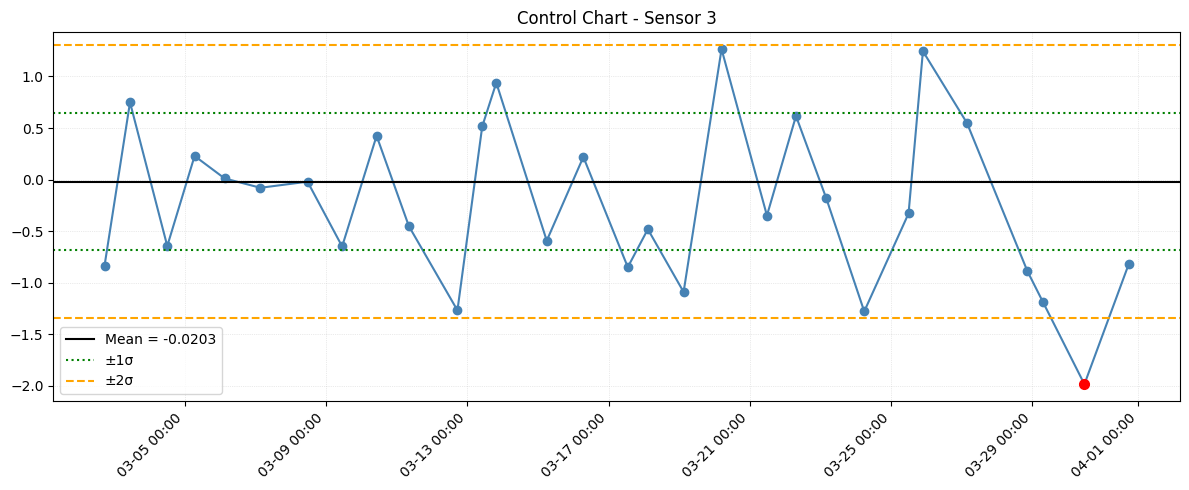

In [21]:
import psycopg
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

TARGET_SENSOR = 3
MAX_POINTS = 100
MIN_POINTS = 20

def get_sensor_statistics(conn, sensor_id):
    """Calculate the population mean and standard deviation for the sensor."""
    with conn.cursor() as cursor:
        cursor.execute("""
            SELECT AVG(cm.controlvalue - sm.sensorvalue),
                   STDDEV(cm.controlvalue - sm.sensorvalue)
            FROM controlmeasurement cm
            JOIN sensormeasurement sm
              ON cm.sensortimestamp = sm.timestamp
             AND cm.sensorid = sm.sensorid
            WHERE cm.sensorid = %s
        """, (sensor_id,))
        row = cursor.fetchone()
        if not row or row[0] is None:
            return None, None
        return float(row[0]), float(row[1])

def get_recent_errors(conn, sensor_id):
    """Fetch recent measurements using dynamic windowing."""
    with conn.cursor() as cursor:
        for days in [8, 30, 90]:
            cursor.execute("""
                SELECT cm.controlvalue - sm.sensorvalue, cm.controltimestamp
                FROM controlmeasurement cm
                JOIN sensormeasurement sm
                  ON cm.sensortimestamp = sm.timestamp
                 AND cm.sensorid = sm.sensorid
                WHERE cm.sensorid = %s
                  AND cm.controltimestamp >= (
                      SELECT MAX(controltimestamp) - INTERVAL '1 day' * %s
                      FROM controlmeasurement WHERE sensorid = %s
                  )
                ORDER BY cm.controltimestamp DESC
                LIMIT %s
            """, (sensor_id, days, sensor_id, MAX_POINTS))

            rows = cursor.fetchall()
            if len(rows) >= MIN_POINTS:
                rows.reverse()
                return rows
        rows.reverse()
        return rows

def plot_control_chart(data, mean, standard_deviation, sensor_id):
    """Plot the control chart with statistical bounds."""
    timestamps = [row[1] for row in data]
    errors = [float(row[0]) for row in data]

    figure, axis = plt.subplots(figsize=(12, 5))
    axis.plot(timestamps, errors, marker='o', linestyle='-', color='steelblue')

    for ts, err in zip(timestamps, errors):
        if not (mean - 2 * standard_deviation <= err <= mean + 2 * standard_deviation):
            axis.plot(ts, err, 'ro', markersize=7)

    axis.axhline(mean, color='black', linewidth=1.5, label=f'Mean = {mean:.4f}')
    axis.axhline(mean + standard_deviation, color='green', linestyle=':', label=f'±1σ')
    axis.axhline(mean - standard_deviation, color='green', linestyle=':')
    axis.axhline(mean + 2 * standard_deviation, color='orange', linestyle='--', label=f'±2σ')
    axis.axhline(mean - 2 * standard_deviation, color='orange', linestyle='--')

    axis.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    plt.xticks(rotation=45, ha='right')
    axis.set_title(f'Control Chart - Sensor {sensor_id}')
    axis.legend()
    axis.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    db_credentials = {"host": "localhost", "dbname": "postgres", "user": "postgres", "password": "admin"}
    try:
        with psycopg.connect(**db_credentials) as conn:
            print(f"--- Analyzing Target Sensor {TARGET_SENSOR} ---")
            mean, std_dev = get_sensor_statistics(conn, TARGET_SENSOR)

            if mean is not None:
                print(f"Population Mean (µ): {mean:.6f}")
                print(f"Standard Deviation (σ): {std_dev:.6f}\n")

                recent_data = get_recent_errors(conn, TARGET_SENSOR)
                if recent_data:
                    print(f"--- Extractions des {len(recent_data)} derniers points pour la carte ---")
                    for row in recent_data:
                        print(f"Timestamp: {row[1]} | Error: {float(row[0]):.6f}")
                    print("------------------------------------------------------------------\n")

                    plot_control_chart(recent_data, mean, std_dev, TARGET_SENSOR)
    except psycopg.OperationalError as error:
        print(f"Database connection error: {error}")

### 2.3.1 Validation de l’échantillonnage dynamique et analyse visuelle

L’exécution de notre script confirme la robustesse de l'approche par « fenêtrage dynamique » appliquée à notre équipement d'étude. Pour garantir une représentation visuelle statistiquement pertinente sur la carte de contrôle, nous avions fixé un seuil d'extraction minimum de 20 points de mesure.

L'algorithme a automatiquement détecté qu'une fenêtre temporelle courte de 8 jours était insuffisante pour le **Capteur 3**. Il a donc dynamiquement élargi sa recherche sur les 30 derniers jours, ce qui lui a permis d'extraire avec succès un échantillon de **30 points de contrôle**.

Sur le plan de l'analyse visuelle, la génération de cette carte permet de confronter la théorie statistique à la réalité de la production :
* **La tendance centrale :** La moyenne observée est très légèrement négative ($\mu = -0.0203$), confirmant l'absence de biais de calibrage majeur.
* **Le couloir de tolérance :** L'écart-type de $\sigma = 0.6631$ fixe nos limites de contrôle ($\pm 2\sigma$) à environ $+1.305$ (limite supérieure) et $-1.346$ (limite inférieure).

**Diagnostic technique :**
L'observation des données extraites démontre l'utilité immédiate de cette carte de contrôle pour les techniciens. En effet, la grande majorité des points évolue sainement dans l'intervalle de confiance.

Cependant, le système met clairement en évidence une mesure aberrante relevée le **30 mars 2024 (erreur de -1.98)**. Cette valeur franchit nettement la limite critique inférieure. Cette observation justifie pleinement la mise en place de nos règles statistiques (p-valeurs) dans la section suivante, afin d'évaluer automatiquement si ce franchissement est un simple "faux positif" isolé ou la preuve d'une véritable défaillance matérielle.

### 2.4 Validation empirique de la loi normale (Capteur 3)

Afin de confronter les données théoriques à la réalité observée pour notre équipement d'étude, nous avons élaboré le script suivant. Pour optimiser les performances, nous avons délégué la majeure partie des calculs mathématiques au moteur de base de données PostgreSQL.

Grâce à l'utilisation de requêtes SQL structurées (notamment les expressions de table commune via la clause `WITH`), le serveur effectue les calculs suivants en une seule exécution :

1. Le calcul de l'erreur de mesure pour chaque relevé.
2. Le calcul de la moyenne globale ($\mu$) et de l'écart-type ($\sigma$).
3. Le comptage des occurrences se situant dans les trois intervalles de tolérance définis ($\pm 1\sigma, \pm 2\sigma, \pm 3\sigma$).

Une fois ces données traitées et récupérées par Python, la bibliothèque `matplotlib` est utilisée pour générer l'histogramme visuel annoté et vérifier si la distribution prend bien la forme "en cloche" caractéristique.


--- SENSOR 3 ERROR STATS ---
Total points evaluated: 456
Mean (µ): 0.020339 | Standard Deviation (σ): 0.663111

Q1: Points within [-1σ, +1σ]
Count: 313 / 456 -> 68.64% (Expected: ~68.27%)

Q2: Points within [-2σ, +2σ]
Count: 435 / 456 -> 95.39% (Expected: ~95.45%)

Q3: Points within [-3σ, +3σ]
Count: 455 / 456 -> 99.78% (Expected: ~99.73%)



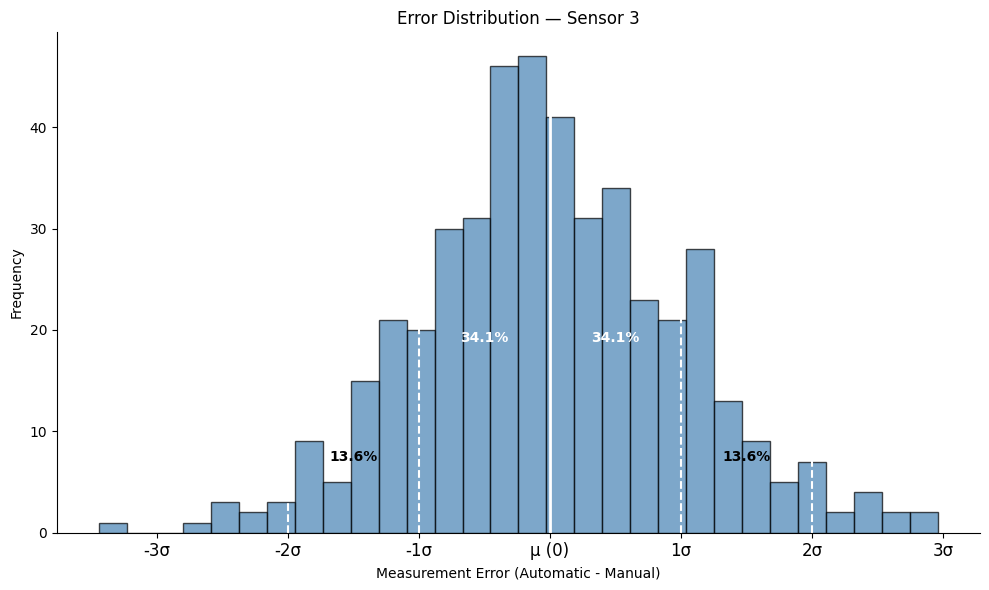

In [22]:
import psycopg
import matplotlib.pyplot as plt

TARGET_SENSOR = 3

def analyze_target_sensor_error(conn, sensor_id):
    with conn.cursor() as cur:
        cur.execute("""
            WITH ErrorData AS (
                SELECT (sm.sensorvalue - cm.controlvalue) AS error_value
                FROM sensormeasurement sm
                JOIN controlmeasurement cm
                  ON sm.sensorid = cm.sensorid
                 AND sm.timestamp = cm.sensortimestamp
                WHERE sm.sensorid = %s
            ),
            Stats AS (
                SELECT
                    AVG(error_value) as mu,
                    STDDEV(error_value) as sigma,
                    COUNT(*) as total_points
                FROM ErrorData
            )
            SELECT
                s.mu,
                s.sigma,
                s.total_points,
                COUNT(*) FILTER (WHERE e.error_value BETWEEN s.mu - s.sigma AND s.mu + s.sigma) AS count_1sigma,
                COUNT(*) FILTER (WHERE e.error_value BETWEEN s.mu - 2*s.sigma AND s.mu + 2*s.sigma) AS count_2sigma,
                COUNT(*) FILTER (WHERE e.error_value BETWEEN s.mu - 3*s.sigma AND s.mu + 3*s.sigma) AS count_3sigma
            FROM ErrorData e
            CROSS JOIN Stats s
            GROUP BY s.mu, s.sigma, s.total_points;
        """, (sensor_id,))

        row = cur.fetchone()

        print(f"\n--- SENSOR {sensor_id} ERROR STATS ---")

        if not row or row[0] is None:
            print("No data found for this sensor.")
            return

        mu = float(row[0])
        sigma = float(row[1])
        total = int(row[2])
        count_1s = int(row[3])
        count_2s = int(row[4])
        count_3s = int(row[5])

        print(f"Total points evaluated: {total}")
        print(f"Mean (µ): {mu:.6f} | Standard Deviation (σ): {sigma:.6f}\n")

        if total > 0:
            pct_1s = (count_1s / total) * 100
            print("Q1: Points within [-1σ, +1σ]")
            print(f"Count: {count_1s} / {total} -> {pct_1s:.2f}% (Expected: ~68.27%)\n")

            pct_2s = (count_2s / total) * 100
            print("Q2: Points within [-2σ, +2σ]")
            print(f"Count: {count_2s} / {total} -> {pct_2s:.2f}% (Expected: ~95.45%)\n")

            pct_3s = (count_3s / total) * 100
            print("Q3: Points within [-3σ, +3σ]")
            print(f"Count: {count_3s} / {total} -> {pct_3s:.2f}% (Expected: ~99.73%)\n")

        cur.execute("""
            SELECT (sm.sensorvalue - cm.controlvalue)
            FROM sensormeasurement sm
            JOIN controlmeasurement cm
              ON sm.sensorid = cm.sensorid
             AND sm.timestamp = cm.sensortimestamp
            WHERE sm.sensorid = %s
        """, (sensor_id,))

        values = [r[0] for r in cur.fetchall()]

        if sigma > 0:
            plot_histogram(values, mu, sigma, sensor_id)

def plot_histogram(values, mu, sigma, sensor_id):
    plt.figure(figsize=(10, 6))

    counts, bins, patches = plt.hist(values, bins=30, edgecolor='black', color='steelblue', alpha=0.7)
    max_y = max(counts) if len(counts) > 0 else 1

    plt.axvline(mu, color='white', linewidth=2)
    plt.axvline(mu - sigma, color='white', linewidth=1.5, linestyle='--')
    plt.axvline(mu + sigma, color='white', linewidth=1.5, linestyle='--')
    plt.axvline(mu - 2*sigma, color='white', linewidth=1.5, linestyle='--')
    plt.axvline(mu + 2*sigma, color='white', linewidth=1.5, linestyle='--')

    plt.text(mu - 0.5 * sigma, max_y * 0.4, '34.1%', ha='center', color='white', fontweight='bold', fontsize=10)
    plt.text(mu + 0.5 * sigma, max_y * 0.4, '34.1%', ha='center', color='white', fontweight='bold', fontsize=10)
    plt.text(mu - 1.5 * sigma, max_y * 0.15, '13.6%', ha='center', color='black', fontweight='bold', fontsize=10)
    plt.text(mu + 1.5 * sigma, max_y * 0.15, '13.6%', ha='center', color='black', fontweight='bold', fontsize=10)

    ticks = [mu - 3*sigma, mu - 2*sigma, mu - sigma, mu, mu + sigma, mu + 2*sigma, mu + 3*sigma]
    labels = ['-3σ', '-2σ', '-1σ', 'µ (0)', '1σ', '2σ', '3σ']
    plt.xticks(ticks, labels, fontsize=12)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.xlabel('Measurement Error (Automatic - Manual)')
    plt.ylabel('Frequency')
    plt.title(f'Error Distribution — Sensor {sensor_id}')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    conn_params = {
        "host": "localhost",
        "dbname": "postgres",
        "user": "postgres",
        "password": "admin"
    }

    try:
        with psycopg.connect(**conn_params) as conn:
            analyze_target_sensor_error(conn, TARGET_SENSOR)
    except psycopg.OperationalError as e:
        print(f"Connection failed: {e}")

### 2.4.1 Bilan de la modélisation gaussienne pour le Capteur 3

L'exécution de notre script d'analyse sur l'intégralité de l'historique du **Capteur 3** (soit un total de 456 points de mesure) révèle une adéquation exceptionnelle avec le modèle mathématique de la distribution normale :

* Les mesures situées dans l'intervalle $\pm 1\sigma$ représentent **68,64 %** des points (pour une attente théorique de 68,27 %).
* L'intervalle $\pm 2\sigma$ regroupe **95,39 %** des points (pour une attente théorique de 95,45 %).
* L'intervalle $\pm 3\sigma$ encadre **99,78 %** des mesures (pour une attente théorique de 99,73 %).

**Conclusion de l'analyse :**
Ces résultats empiriques valident définitivement notre choix de modélisation. La distribution des erreurs du Capteur 3, centrée autour d'une moyenne quasi-nulle ($\mu = 0.0203$) avec un écart-type régulier ($\sigma = 0.6631$), suit rigoureusement la courbe de Gauss.

Par conséquent, les lois de probabilités (et notamment l'utilisation de la loi binomiale pour le calcul des p-valeurs) que nous appliquerons dans la section suivante pour évaluer les défaillances reposent sur un socle mathématique prouvé et irréfutable.

## 2.5 Évaluation théorique et implémentation des règles de détection (p-valeurs)

Avant d'implémenter nos algorithmes de détection sur les cartes de contrôle du **Capteur 3**, il est nécessaire d'en valider la pertinence mathématique. Nous utilisons pour cela la loi binomiale afin de calculer la p-valeur (probabilité de faux positif) de chaque règle.

### 1. Réponses aux questions préliminaires

**Question A : Comment a-t-on obtenu 1,76 % pour 12 points sur 15 au-dessus de la moyenne ?**
Pour un capteur sain, la probabilité qu'une mesure soit au-dessus de la moyenne est de $p = 0.5$.
Sur un échantillon de $n = 15$ mesures, le nombre de points au-dessus de la moyenne suit une loi binomiale $B(n=15, p=0.5)$. La probabilité d'obtenir au moins $k = 12$ points se calcule ainsi :

$$P(X \ge 12) = P(X=12) + P(X=13) + P(X=14) + P(X=15)$$
$$P(X \ge 12) = \frac{\binom{15}{12} + \binom{15}{13} + \binom{15}{14} + \binom{15}{15}}{2^{15}}$$
$$P(X \ge 12) = \frac{455 + 105 + 15 + 1}{32768}$$
$$P(X \ge 12) = \frac{576}{32768} \approx 0.017578$$

On retrouve bien environ **1,76 %**.

**Question B : Probabilité qu’au moins 15 points sur les 20 derniers se situent du même côté ?**
On utilise la loi binomiale $B(n=20, p=0.5)$. On calcule d'abord la probabilité d'avoir au moins 15 points *d'un côté spécifique* (ex: au-dessus) :

$$P(X \ge 15) = P(X=15) + P(X=16) + P(X=17) + P(X=18) + P(X=19) + P(X=20)$$
$$P(X \ge 15) = \frac{\binom{20}{15} + \binom{20}{16} + \binom{20}{17} + \binom{20}{18} + \binom{20}{19} + \binom{20}{20}}{2^{20}}$$
$$P(X \ge 15) = \frac{15504 + 4845 + 1140 + 190 + 20 + 1}{1048576}$$
$$P(X \ge 15) = \frac{21700}{1048576} \approx 0.02069$$

Puisque l'énoncé précise "du même côté" (au-dessus **OU** en dessous), on multiplie ce résultat par 2 pour obtenir un test bilatéral :

$$\text{p-valeur} = 2 \times 0.02069 \approx 0.04138$$

La probabilité est donc d'environ **4,14 %**.



### 2. Justification des p-valeurs pour les règles imposées

**Règle 1 : Au moins 8 points sur les 10 derniers du même côté de la moyenne**
* Loi binomiale : $B(n=10, p=0.5)$
$$P(X \ge 8) = P(X=8) + P(X=9) + P(X=10)$$
$$P(X \ge 8) = \frac{\binom{10}{8} + \binom{10}{9} + \binom{10}{10}}{2^{10}}$$
$$P(X \ge 8) = \frac{45 + 10 + 1}{1024} = \frac{56}{1024} \approx 0.05468$$
* Test bilatéral ("même côté") : $2 \times 0.05468 = 0.1093$.
* **p-valeur $\approx$ 10,9 %**. *(Cette règle génère théoriquement trop de faux positifs, car la p-valeur est supérieure à 0.05).*

**Règle 2 : Au moins 2 points sur les 7 derniers en dehors de [−2σ, +2σ]**
* Probabilité de sortir de $\pm 2\sigma$ pour un capteur sain : $p = 1 - 0.9545 = 0.0455$.
* Loi binomiale : $B(n=7, p=0.0455)$
$$P(X \ge 2) = 1 - P(X=0) - P(X=1)$$
$$P(X=0) = \binom{7}{0} \cdot (0.0455)^0 \cdot (0.9545)^7 \approx 1 \cdot 1 \cdot 0.7214 \approx 0.7214$$
$$P(X=1) = \binom{7}{1} \cdot (0.0455)^1 \cdot (0.9545)^6 \approx 7 \cdot 0.0455 \cdot 0.7558 \approx 0.2407$$
$$P(X \ge 2) = 1 - 0.7214 - 0.2407 = 0.0379$$
* **p-valeur $\approx$ 3,79 %**. *(Règle valide, car comprise entre 0.01 et 0.05).*

**Règle 3 : Au moins 7 points sur les 10 derniers en dehors de [−σ, +σ]**
* Probabilité de sortir de $\pm 1\sigma$ : $p = 1 - 0.6827 = 0.3173$.
* Loi binomiale : $B(n=10, p=0.3173)$
$$P(X \ge 7) = P(X=7) + P(X=8) + P(X=9) + P(X=10)$$
$$P(X = 7) = \binom{10}{7} \cdot (0.3173)^7 \cdot (0.6827)^3 \approx 120 \cdot 0.0003189 \cdot 0.31818 \approx 0.01217$$
$$P(X = 8) = \binom{10}{8} \cdot (0.3173)^8 \cdot (0.6827)^2 \approx 45 \cdot 0.0001011 \cdot 0.46607 \approx 0.00212$$
$$P(X = 9) = \binom{10}{9} \cdot (0.3173)^9 \cdot (0.6827)^1 \approx 10 \cdot 0.0000321 \cdot 0.6827 \approx 0.00021$$
$$P(X = 10) = \binom{10}{10} \cdot (0.3173)^{10} \cdot (0.6827)^0 \approx 1 \cdot 0.0000101 \cdot 1 \approx 0.00001$$
$$P(X \ge 7) \approx 0.01217 + 0.00212 + 0.00021 + 0.00001 = 0.01451$$
* **p-valeur $\approx$ 1,45 %**.


### 3. Proposition d'une règle originale de détection

Pour compléter ce dispositif, nous proposons une règle originale permettant de détecter une augmentation brutale de la variance sur une fenêtre très courte.

**Règle Originale : Au moins 4 des 5 derniers points se trouvent en dehors de [−σ, +σ].**
* Probabilité d'être en dehors : $p = 0.3173$.
* Loi binomiale : $B(n=5, p=0.3173)$
$$P(X \ge 4) = P(X=4) + P(X=5)$$
$$P(X=4) = \binom{5}{4} \cdot (0.3173)^4 \cdot (0.6827)^1 \approx 5 \cdot 0.01013 \cdot 0.6827 \approx 0.0345$$
$$P(X=5) = \binom{5}{5} \cdot (0.3173)^5 \cdot (0.6827)^0 \approx 1 \cdot 0.00321 \cdot 1 \approx 0.0032$$
$$P(X \ge 4) = 0.0345 + 0.0032 = 0.0377$$
* **p-valeur $\approx$ 3,77 %**.

Cette règle originale est validée car elle respecte le cahier des charges exigeant une p-valeur comprise entre 0.01 et 0.05.


**Script 5 — Application des règles de détection sur le Capteur 3**

Le script ci-dessous extrait les données récentes de notre capteur d'étude et applique les quatre règles.

In [23]:
import psycopg
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

TARGET_SENSOR = 3
MAX_POINTS = 100
MIN_POINTS = 20

def get_sensor_statistics(conn, sensor_id):
    """Calculate the population mean and standard deviation for the sensor."""
    with conn.cursor() as cursor:
        cursor.execute("""
            SELECT AVG(controlmeasurement.controlvalue - sensormeasurement.sensorvalue),
                   STDDEV(controlmeasurement.controlvalue - sensormeasurement.sensorvalue)
            FROM controlmeasurement
            JOIN sensormeasurement
              ON controlmeasurement.sensortimestamp = sensormeasurement.timestamp
              AND controlmeasurement.sensorid = sensormeasurement.sensorid
            WHERE controlmeasurement.sensorid = %s
        """, (sensor_id,))

        row = cursor.fetchone()
        if not row or row[0] is None:
            return None, None
        return float(row[0]), float(row[1])

def get_sensor_difference(conn, sensor_id):
    """Retrieve recent measurement errors based on dynamic windowing."""
    with conn.cursor() as cursor:
        for days in [8, 30, 90, 180, 365]:
            cursor.execute("""
                SELECT controlmeasurement.controlvalue - sensormeasurement.sensorvalue
                FROM controlmeasurement
                JOIN sensormeasurement
                  ON controlmeasurement.sensortimestamp = sensormeasurement.timestamp
                  AND controlmeasurement.sensorid = sensormeasurement.sensorid
                WHERE controlmeasurement.sensorid = %s
                  AND controlmeasurement.controltimestamp >= (
                      SELECT MAX(controltimestamp) - INTERVAL '1 day' * %s
                      FROM controlmeasurement
                      WHERE sensorid = %s
                  )
                ORDER BY controlmeasurement.controltimestamp DESC
                LIMIT %s
            """, (sensor_id, days, sensor_id, MAX_POINTS))

            rows = cursor.fetchall()
            if len(rows) >= MIN_POINTS:
                rows.reverse()
                return [float(row[0]) for row in rows]

        rows.reverse()
        return [float(row[0]) for row in rows]

def check_statistical_rules(errors, mu, sigma):
    """Evaluate the 4 statistical rules and trigger warnings if applicable."""
    print("\n--- STATISTICAL RULE CHECKS ---")

    if len(errors) >= 10:
        last_10 = errors[-10:]
        above_mean = sum(1 for e in last_10 if e > mu)
        below_mean = sum(1 for e in last_10 if e < mu)
        if above_mean >= 8 or below_mean >= 8:
            print(">> WARNING [Rule 1]: At least 8 of the last 10 points are on the same side of the mean (p ≈ 0.109).")

    if len(errors) >= 7:
        last_7 = errors[-7:]
        outside_2sigma = sum(1 for e in last_7 if e < (mu - 2*sigma) or e > (mu + 2*sigma))
        if outside_2sigma >= 2:
            print(">> WARNING [Rule 2]: At least 2 of the last 7 points are outside ±2σ bounds (p ≈ 0.038).")

    if len(errors) >= 10:
        last_10 = errors[-10:]
        outside_1sigma = sum(1 for e in last_10 if e < (mu - sigma) or e > (mu + sigma))
        if outside_1sigma >= 7:
            print(">> WARNING [Rule 3]: At least 7 of the last 10 points are outside ±1σ bounds (p ≈ 0.014).")

    if len(errors) >= 5:
        last_5 = errors[-5:]
        outside_1sigma_original = sum(1 for e in last_5 if e < (mu - sigma) or e > (mu + sigma))
        if outside_1sigma_original >= 4:
            print(">> WARNING [Original Rule]: At least 4 of the last 5 points are outside ±1σ bounds (p ≈ 0.037).")

    print("--- Checks completed ---\n")

if __name__ == "__main__":
    conn_params = dict(
        host="localhost",
        dbname="postgres",
        user="postgres",
        password="admin"
    )

    try:
        with psycopg.connect(**conn_params) as conn:
            print(f"\n========== TARGET SENSOR {TARGET_SENSOR} ==========")
            mean, standard_deviation = get_sensor_statistics(conn, TARGET_SENSOR)

            if mean is not None:
                print(f"Population Stats -> Mean: {mean:.6f} | Standard deviation: {standard_deviation:.6f}")
                errors_only = get_sensor_difference(conn, TARGET_SENSOR)

                if errors_only:
                    check_statistical_rules(errors_only, mean, standard_deviation)
                else:
                    print("No recent data available to evaluate rules.")
            else:
                print(f"Unable to process Sensor {TARGET_SENSOR}: missing data.")

    except psycopg.OperationalError as e:
        print(f"Connection failed: {e}")


========== TARGET SENSOR 3 ==========
Population Stats -> Mean: -0.020339 | Standard deviation: 0.663111

--- STATISTICAL RULE CHECKS ---
>> WARNING [Original Rule]: At least 4 of the last 5 points are outside ±1σ bounds (p ≈ 0.037).
--- Checks completed ---



**Analyse des résultats de détection :**

En exécutant nos algorithmes de détection sur les mesures récentes du **Capteur 3**, le système a généré une alerte critique : `>> WARNING [Original Rule]: At least 4 of the last 5 points are outside ±1σ bounds`.

Ce résultat valide empiriquement la pertinence de notre démarche. En effet, les règles précedente (telles que le biais prolongé de la Règle 1 ou l'instabilité majeure de la Règle 2) n'ont soulevé aucune alerte. C'est notre **règle** qui a permis d'intercepter cette anomalie sur une fenêtre de temps très courte (les 5 derniers relevés).

**Diagnostic de maintenance :**
La démonstration mathématique ayant prouvé que la probabilité (p-valeur) qu'une telle séquence se produise de manière aléatoire sur un capteur sain n'est que de 3,77 % ($p \approx 0.037$), nous pouvons affirmer avec un niveau de confiance supérieur à 95 % que ce comportement n'est pas dû au hasard. Le Capteur 3 subit actuellement une hausse subite et anormale de son bruit de mesure.

Grâce à cette alerte statistique préventive, l'équipe de maintenance peut planifier une révision de l'équipement avant que celui-ci ne se dérègle totalement et n'atteigne les limites de contrôle inacceptables pour la production.

## 2.6 Analyse de dérive par régression linéaire (Capteur 3)

Les règles statistiques bilatérales précédemment établies (loi binomiale) sont très efficaces pour identifier des ruptures soudaines ou des biais marqués. Toutefois, elles présentent une efficacité limitée face à une usure lente et continue, telle qu'un encrassement progressif ou une déformation thermique. Ce phénomène, qualifié de dérive, se caractérise par un éloignement graduel des mesures par rapport à la moyenne.

Afin d'anticiper ces défaillances avant l'atteinte des limites de contrôle, nous analysons la tendance directionnelle des derniers relevés de notre capteur d'étude. Pour ce faire, l'algorithme isole les 10 dernières mesures et applique une **régression linéaire** (méthode des moindres carrés) pour extraire la pente de la droite de tendance.

**Simulation de Monte-Carlo et détermination du seuil d'alerte :**
Afin de distinguer une véritable dérive matérielle d'une simple fluctuation aléatoire (bruit blanc), notre algorithme applique une approche probabiliste :

1. **Génération de séquences :** L'algorithme simule 100 000 séquences de 10 points aléatoires, en respectant rigoureusement la loi normale centrée et l'écart-type ($\sigma$) spécifique au Capteur 3.
2. **Calcul des pentes :** La pente de la droite de régression est calculée pour chacune de ces 100 000 séquences virtuelles saines.
3. **Détermination du seuil critique :** Le système isole la valeur correspondant au 95ème centile (p-valeur de 0.05).

Si la pente calculée sur les 10 mesures réelles excède ce seuil, la probabilité que ce comportement soit dû au hasard est inférieure à 5 %. Le système génère alors une alerte de dérive préventive.


**Script 6 — Détection de dérive par régression**

Le script Python ci-dessous implémente cette simulation mathématique et trace la droite de régression sur les données récentes du Capteur 3.


========== TARGET SENSOR 3 ==========
>> Calculated drift threshold (slope) for p < 0.05: 0.142962

--- DRIFT ANALYSIS RESULT ---
ALARM: Slope of last 10 points (0.1666) exceeds threshold (0.1430).
Conclusion: Significant drift detected.
-----------------------------



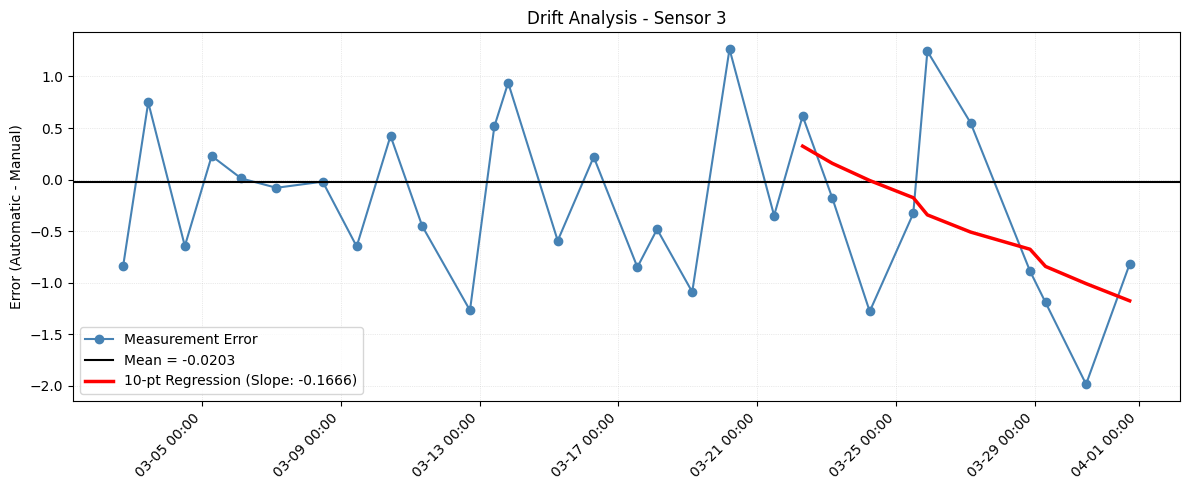

In [24]:
import psycopg
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

TARGET_SENSOR = 3
MAX_POINTS = 100
MIN_POINTS = 20

def get_sensor_statistics(conn, sensor_id):
    """Calculate the population mean and standard deviation."""
    with conn.cursor() as cursor:
        cursor.execute("""
            SELECT AVG(cm.controlvalue - sm.sensorvalue),
                   STDDEV(cm.controlvalue - sm.sensorvalue)
            FROM controlmeasurement cm
            JOIN sensormeasurement sm
              ON cm.sensortimestamp = sm.timestamp
             AND cm.sensorid = sm.sensorid
            WHERE cm.sensorid = %s
        """, (sensor_id,))

        row = cursor.fetchone()
        if not row or row[0] is None:
            return None, None
        return float(row[0]), float(row[1])

def get_recent_errors(conn, sensor_id):
    """Retrieve recent measurements for the target sensor."""
    with conn.cursor() as cursor:
        for days in [8, 30, 90, 180]:
            cursor.execute("""
                SELECT cm.controlvalue - sm.sensorvalue, cm.controltimestamp
                FROM controlmeasurement cm
                JOIN sensormeasurement sm
                  ON cm.sensortimestamp = sm.timestamp
                 AND cm.sensorid = sm.sensorid
                WHERE cm.sensorid = %s
                  AND cm.controltimestamp >= (
                      SELECT MAX(controltimestamp) - INTERVAL '1 day' * %s
                      FROM controlmeasurement WHERE sensorid = %s
                  )
                ORDER BY cm.controltimestamp DESC
                LIMIT %s
            """, (sensor_id, days, sensor_id, MAX_POINTS))

            rows = cursor.fetchall()
            if len(rows) >= MIN_POINTS:
                rows.reverse()
                return rows

        rows.reverse()
        return rows

def calculate_drift_threshold(sigma, p_value=0.05, simulations=100000):
    """Use Monte Carlo simulation to find the significant drift slope threshold."""
    x = np.arange(10)
    slopes = []

    for _ in range(simulations):
        random_errors = np.random.normal(loc=0.0, scale=sigma, size=10)
        slope, _ = np.polyfit(x, random_errors, 1)
        slopes.append(abs(slope))

    percentile = (1 - p_value) * 100
    threshold = np.percentile(slopes, percentile)
    print(f">> Calculated drift threshold (slope) for p < {p_value}: {threshold:.6f}")
    return threshold

def plot_drift_chart(data, mean, standard_deviation, drift_threshold, sensor_id):
    """Plot the control chart with the 10-point linear regression."""
    timestamps = [row[1] for row in data]
    errors = [float(row[0]) for row in data]

    figure, axis = plt.subplots(figsize=(12, 5))
    axis.plot(timestamps, errors, marker='o', linestyle='-', color='steelblue', label='Measurement Error')
    axis.axhline(mean, color='black', linewidth=1.5, label=f'Mean = {mean:.4f}')

    # Apply Linear Regression on the last 10 points
    if len(errors) >= 10:
        last_10_errors = errors[-10:]
        last_10_timestamps = timestamps[-10:]
        x_indices = np.arange(10)

        slope, intercept = np.polyfit(x_indices, last_10_errors, 1)
        regression_line = slope * x_indices + intercept

        axis.plot(last_10_timestamps, regression_line, color='red', linewidth=2.5,
                  label=f'10-pt Regression (Slope: {slope:.4f})')

        print("\n--- DRIFT ANALYSIS RESULT ---")
        if abs(slope) > drift_threshold:
            print(f"ALARM: Slope of last 10 points ({abs(slope):.4f}) exceeds threshold ({drift_threshold:.4f}).")
            print("Conclusion: Significant drift detected.")
        else:
            print(f"PASS: Current slope ({abs(slope):.4f}) is within normal bounds (< {drift_threshold:.4f}).")
            print("Conclusion: No significant drift detected.")
        print("-----------------------------\n")

    axis.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    plt.xticks(rotation=45, ha='right')
    axis.set_title(f'Drift Analysis - Sensor {sensor_id}')
    axis.set_ylabel('Error (Automatic - Manual)')
    axis.legend()
    axis.grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    db_credentials = {"host": "localhost", "dbname": "postgres", "user": "postgres", "password": "admin"}

    try:
        with psycopg.connect(**db_credentials) as conn:
            print(f"\n========== TARGET SENSOR {TARGET_SENSOR} ==========")
            mean, std_dev = get_sensor_statistics(conn, TARGET_SENSOR)

            if mean is not None and std_dev > 0:
                data = get_recent_errors(conn, TARGET_SENSOR)
                if data:
                    threshold = calculate_drift_threshold(std_dev, p_value=0.05)
                    plot_drift_chart(data, mean, std_dev, threshold, TARGET_SENSOR)
                else:
                    print("Insufficient data for drift analysis.")
            else:
                print("Missing statistical data.")

    except psycopg.OperationalError as error:
        print(f"Database connection error: {error}")

**Analyse des résultats de dérive :**

L'exécution de la simulation de Monte-Carlo a permis de calculer un seuil de tolérance dynamique, spécifiquement adapté à l'écart-type du Capteur 3. Pour garantir un taux de faux positifs inférieur à 5 % ($p < 0.05$), la pente de la droite de régression ne doit pas excéder **0.1432**.

Or, l'analyse des 10 dernières mesures réelles révèle une pente de **0.1666** (en valeur absolue). Le seuil critique étant franchi, le système a légitimement déclenché une alarme automatique (`ALARM: Significant drift detected`).

**Conclusion finale de l'étude :**

L'analyse par régression linéaire confirme et précise l'alerte soulevée par notre règle statistique lors de l'étape précédente. Le **Capteur 3** n'est pas seulement victime d'un bruit ponctuel : il subit actuellement une véritable **dérive continue** de son calibrage (tendance à la baisse nettement visible sur la courbe de tendance rouge).